# **Directed percolation in Rust-Python**

Demo simulation of directed percolation on a 1d lattice.

<hr>

## Preliminaries

In [1]:
from essentials import *
dprs.__version__

'2026.4.12'

<hr>

## Parameters

In [2]:
class Parameters:
    # growth_model_choice = GrowthModelChoice.StaggeredDomanyKinzel
    growth_model_choice = GrowthModelChoice.Bedload
    dim = Dimension.D1
    n_x: int = 1_000
    n_y: int = 1
    n_z: int = 1
    p_1: float = 0.538910
    p_2: float = 0.538910
    # p_1: float = 0.705485152 +0.005
    # p_2: float = 0.705485152 +0.005
    n_iterations: int = 500
    sample_period: int = 1
    initial_condition = InitialCondition.Randomized
    # initial_condition = InitialCondition.CentralSeed
    p_initial: float = 0.99
    random_seed: int = 1
    topology_x = Topology.Periodic
    topology_y = Topology.Unspecified
    topology_z = Topology.Unspecified
    bcs_x = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_y = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
    bcs_z = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
    bc_values_x = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_y = (DUAL.EMPTY.state, DUAL.EMPTY.state)
    bc_values_z = (DUAL.EMPTY.state, DUAL.EMPTY.state)
    do_edge_buffering: bool = True
    processing = Processing.Parallel
    n_threads: int = 16
parameters = Parameters()
# Just in case we forget to update sample_period to match n_iterations
if parameters.sample_period > parameters.n_iterations:
    parameters.sample_period = parameters.n_iterations

<hr>

## Simulation

Execute the Rust-coded sim (for small grids, parallelization can actually slow down the processing):

In [3]:
n_raw_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: Sequence[list]
pruned_tracking: Sequence[list]
t_run_time: float

In [4]:
(n_raw_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dk(parameters)

In [5]:
print(f"Total number of lattice time slices = {n_raw_lattices}\n")

Total number of lattice time slices = 501



<hr>

## Post-processing

The function `sim.dk` returns a subset of the time-series of lattices generated by the simulation, with subsetting given by the `sample_rate` parameter, such that the total number provided is `n_lattices`. Each lattice is returned in flattened form as a 1d list, with all of them concatenated into one long 1d list.

In [6]:
n_lattices: int
lattices: NDArray
tracking: NDArray
(n_lattices, lattices, tracking) \
    = postprocessing(parameters, n_raw_lattices, raw_lattices, raw_tracking,)
lattices.shape

(1000, 501)

<hr>

## Visualization

### Prep

In [7]:
viz = Viz(dpi=125)
name: str

In [8]:
image_lattice_history = partial(
    viz.image_lattice_history,
    lattices=lattices, 
    p=parameters, 
    x=min(parameters.n_x, 500),
    t=min(n_lattices, 1001),
    fig_size=(6, 4,),
)

### Evolution

lattice_p0p538910_s1_nx1000


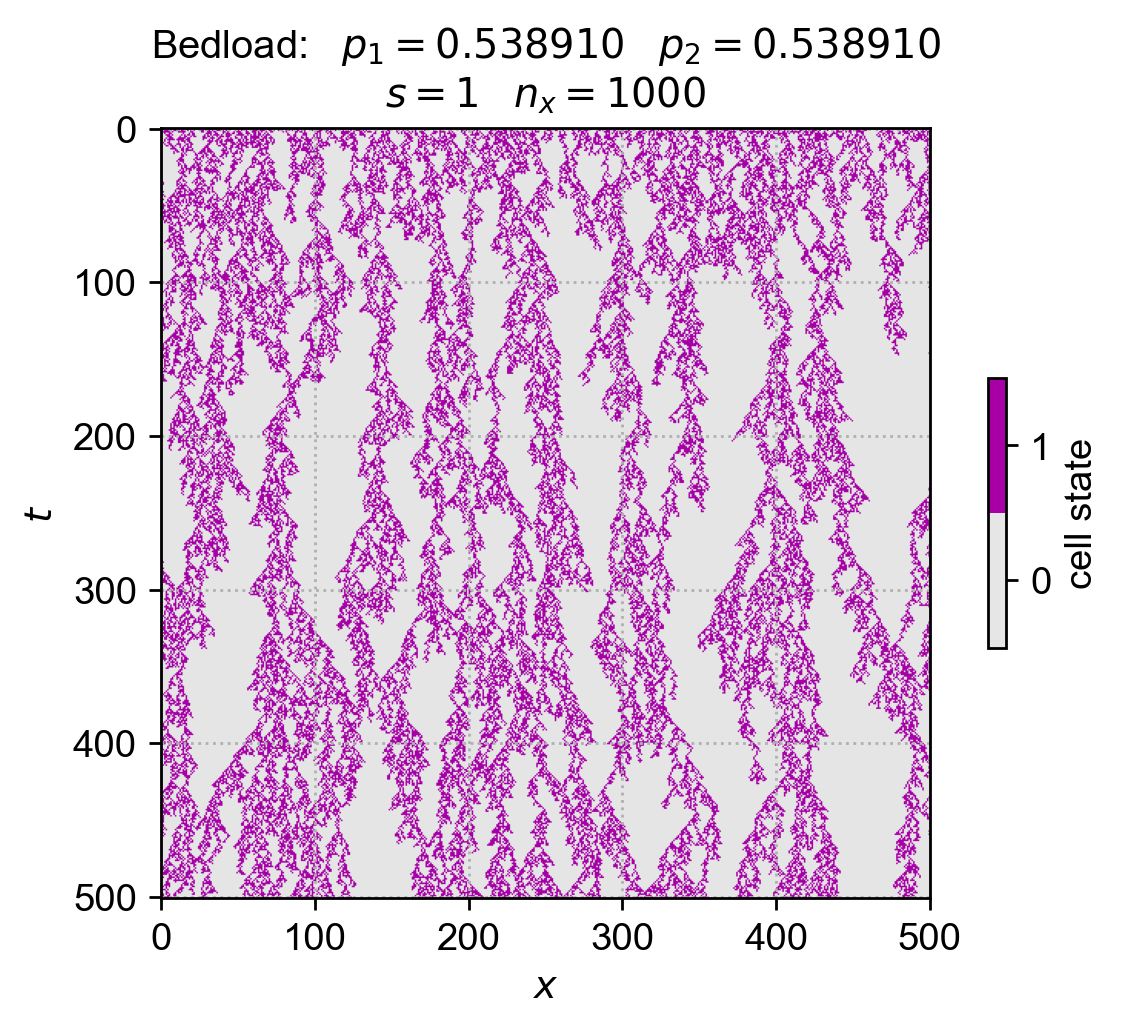

In [9]:
if n_lattices>0:
    i_slice = 0
    name = make_name(parameters, "lattice",)
    print(name)
    image_lattice_history(
        name=name, title=make_title(parameters), 
    )
    plt.show()

### Mean order parameter $t$-decay

See Henkel et al (2008), tables 4.1 and 4.3: the mean order parameter (mean occupancy) $\overline\rho$ should decay with time as
$$
    \rho(t) \sim t^{-\delta}
$$
where in $d=1$ we should find $\delta \approx 0.1594646$. 

ρmean_p0p538910_s1_nx1000


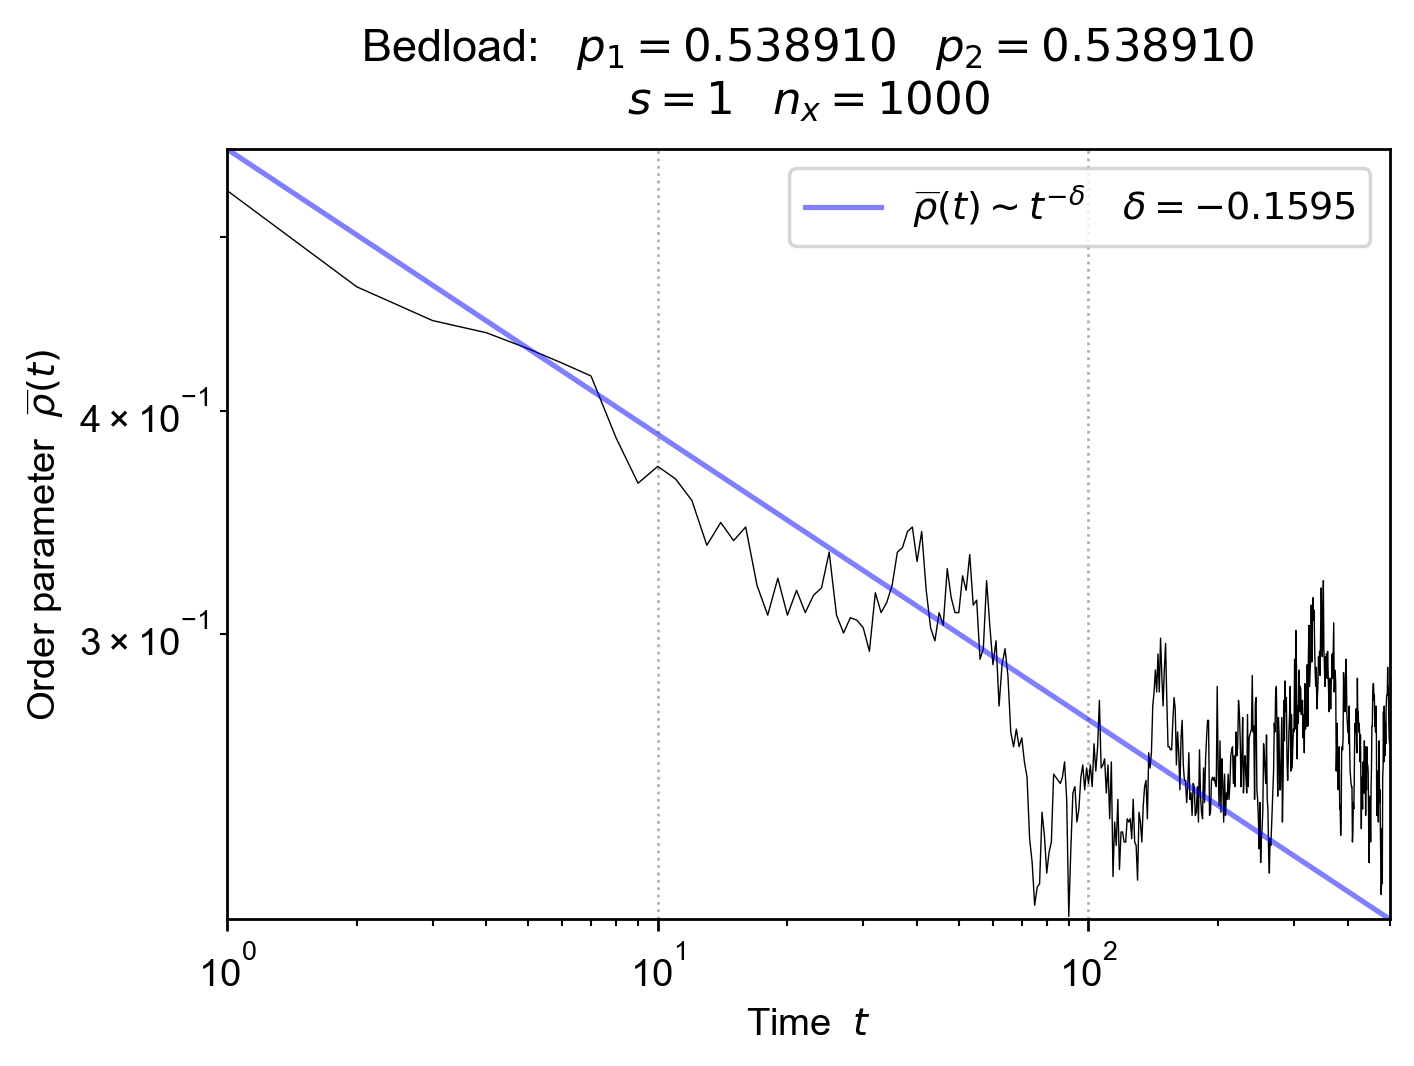

In [10]:
δ = 0.1594646
match parameters.growth_model_choice:
    case GrowthModelChoice.StaggeredDomanyKinzel:
        scale = 0.675
    case GrowthModelChoice.SimplifiedDomanyKinzel:
        scale = 0.56
    case GrowthModelChoice.Bedload:
        scale = 0.56
        
name = make_name(parameters, "ρmean", None, )
print(name)
viz.plot_lattice_statistic(
    name,
    make_title(parameters, None),
    tracking,
    choices=("time", "ρ_mean"),
    labels=(
        "Order parameter  $\\widebar{\\rho}(t)$", 
        "$\\widebar{\\rho}(t) \\sim t^{-\\delta}$",
        "${\\delta}$",
    ),
    exponent=-δ, 
    scale=scale,
    i_offset=1,
    do_ref_curve=True,
)
plt.show()

In [11]:
i_offset: int = parameters.n_iterations//50
t: NDArray = tracking["time"][i_offset:]
ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
(exponent, scale, r_value, p_value, std_err) \
    = linregress(np.log(t), np.log(ρ_mean))
print(f"t range: {t[0]}-{t[-1]}")
print(rf"Estimated t-decay exponent:  δ = {exponent:0.3f}")

t range: 10.0-500.0
Estimated t-decay exponent:  δ = -0.045


### Mean square radius  $t$-decay

In [12]:
if parameters.initial_condition==InitialCondition.CentralSeed:
    z = 1.58074510
    scale = 0.5

    name = make_name(parameters, "Rmean", None, )
    print(name)
    viz.plot_lattice_statistic(
        name,
        make_title(parameters, None),
        tracking,
        choices=("time", "R_mean"),
        labels=(
            "Mean cluster radius  $\\widebar{R}(t)$", 
            "$\\widebar{R}(t) \\sim t^{1/z}$",
            "${1/z}$",
        ),
        exponent=1/z, 
        scale=scale,
        i_offset=1,
        do_ref_curve=True,
    )
    plt.show()

<hr>

## Export

In [13]:
plots_dir: str = create_directories((os.path.curdir,"plots",), "bedload1d")
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

'././plots/bedload1d'